In [11]:
import numpy as np
import matplotlib.pyplot as plt
import odl

import sys
sys.path.append("..")

from src.tomo import (
    make_space_2d,
    shepp_logan_2d,
    parallel_geom_2d,
    ray_transform_2d,
    reconstruct_bp,
    reconstruct_fbp,
)
space = make_space_2d(Nx=256, Ny=256, domain=[-1, 1, -1, 1])
phantom = shepp_logan_2d(space)
phantom_np = phantom.asarray()

angular_coverage=(-60,60)
step = 1
geom = parallel_geom_2d(angular_coverage=angular_coverage, step=step, 
                        det_range=(-1.5, 1.5), det_count=400)
A = ray_transform_2d(space, geom)
data_space = A.range

sinogram = A(phantom)

from src.tomo import add_poisson_noise, add_gaussian_noise, add_poisson_gaussian_noise

I0 = 2e4
# sino_noisy = add_poisson_noise(sino, A, I0=I0)
# sino_noisy = add_gaussian_noise(sino, A, I0=I0, sigma=3.0)
sino_noisy = add_poisson_gaussian_noise(sinogram, A, I0=I0, sigma=2.0)


**Find best frequency filter for noise level (best FBP solution)**
* Measured in relative $L^2$-error against the true phantom

In [12]:
from src.metrics import rel_l2_err
# Find the best FBP solution by looping over all filters, measured by relative L2
error = np.inf
for filter in ["Ram-Lak", "Shepp-Logan", "Cosine", "Hamming", "Hann"]:
    temp = reconstruct_fbp(sino_noisy, A, filter_name=filter)
    temp = temp.asarray()
    temp_error = rel_l2_err(x=temp, xtrue=phantom_np)
    if temp_error < error:
        fbp_best = temp
        error = temp_error
        best_filter = filter

# Reference solution is the FBP with ramp filter (Ram-Lak)
fbp_ref = reconstruct_fbp(sino_noisy, A, filter_name="Ram-Lak")
fbp_ref = fbp_ref.asarray()

In [13]:
from src.siac import siac_cgam

moments = 2
BSorder = 2     # hat spline

cgam = siac_cgam(moments, BSorder)

print("SIAC cosine coefficients:")
for i, c in enumerate(cgam):
    print(f"c_{i} = {c}")

print(f"c_0 should be ~ {7/6}")
print(f"c_1 should be ~ {-1/12}")


SIAC cosine coefficients:
c_0 = 1.1666666666666665
c_1 = -0.08333333333333331
c_0 should be ~ 1.1666666666666667
c_1 should be ~ -0.08333333333333333


In [14]:
import odl, inspect
import odl.tomo.analytic.filtered_back_projection as fbpmod
print(odl.__version__)
print(inspect.getsource(fbpmod._fbp_filter))


0.8.3
def _fbp_filter_patched(norm_freq, filter_type, frequency_scaling):
    """Create a smoothing filter for FBP.

    Parameters
    ----------
    norm_freq : `array-like`
        Frequencies normalized to lie in the interval [0, 1].
    filter_type : {'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann',
                   callable}
        The type of filter to be used.
        If a string is given, use one of the standard filters with that name.
        A callable should take an array of values in [0, 1] and return the
        filter for these frequencies.
    frequency_scaling : float
        Scaling of the frequencies for the filter. All frequencies are scaled
        by this number, any relative frequency above ``frequency_scaling`` is
        set to 0.

    Returns
    -------
    smoothing_filter : `numpy.ndarray`

    Examples
    --------
    Create an FBP filter

    >>> norm_freq = np.linspace(0, 1, 10)
    >>> filt = _fbp_filter(norm_freq,
    ...                    f

### Fixing the ODL internal _fbp_filter
* Fixing it so that it accepts a custom filter

In [15]:
def _fbp_filter_patched(norm_freq, filter_type, frequency_scaling):
    """Create a smoothing filter for FBP.

    Parameters
    ----------
    norm_freq : `array-like`
        Frequencies normalized to lie in the interval [0, 1].
    filter_type : {'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann',
                   callable}
        The type of filter to be used.
        If a string is given, use one of the standard filters with that name.
        A callable should take an array of values in [0, 1] and return the
        filter for these frequencies.
    frequency_scaling : float
        Scaling of the frequencies for the filter. All frequencies are scaled
        by this number, any relative frequency above ``frequency_scaling`` is
        set to 0.

    Returns
    -------
    smoothing_filter : `numpy.ndarray`

    Examples
    --------
    Create an FBP filter

    >>> norm_freq = np.linspace(0, 1, 10)
    >>> filt = _fbp_filter(norm_freq,
    ...                    filter_type='Hann',
    ...                    frequency_scaling=0.8)
    """
    # filter_type, filter_type_in = str(filter_type).lower(), filter_type
    filter_type_in = filter_type    # Add this for error message
    if callable(filter_type):
        filt = filter_type(norm_freq)
    else:   # add else here for string-based call (e.g. "hann")
        filter_type = str(filter_type).lower()
        if filter_type == 'ram-lak':
            filt = np.copy(norm_freq)
        elif filter_type == 'shepp-logan':
            filt = norm_freq * np.sinc(norm_freq / (2 * frequency_scaling))
        elif filter_type == 'cosine':
            filt = norm_freq * np.cos(norm_freq * np.pi / (2 * frequency_scaling))
        elif filter_type == 'hamming':
            filt = norm_freq * (
                0.54 + 0.46 * np.cos(norm_freq * np.pi / (frequency_scaling)))
        elif filter_type == 'hann':
            filt = norm_freq * (
                np.cos(norm_freq * np.pi / (2 * frequency_scaling)) ** 2)
        else:
            raise ValueError('unknown `filter_type` ({})'
                            ''.format(filter_type_in))

    indicator = (norm_freq <= frequency_scaling)
    filt *= indicator
    return filt


# Patch
fbpmod._fbp_filter = _fbp_filter_patched


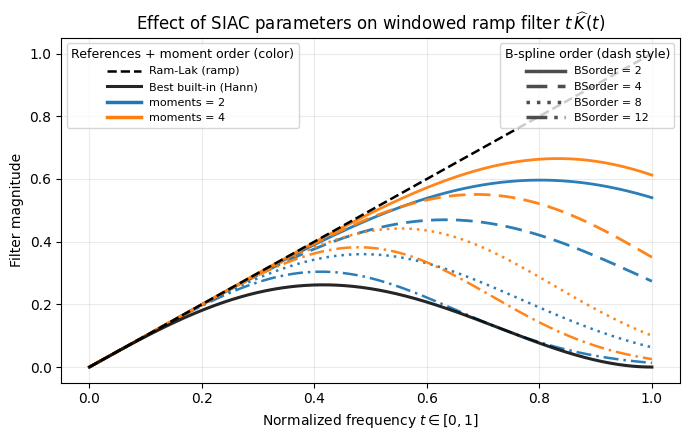

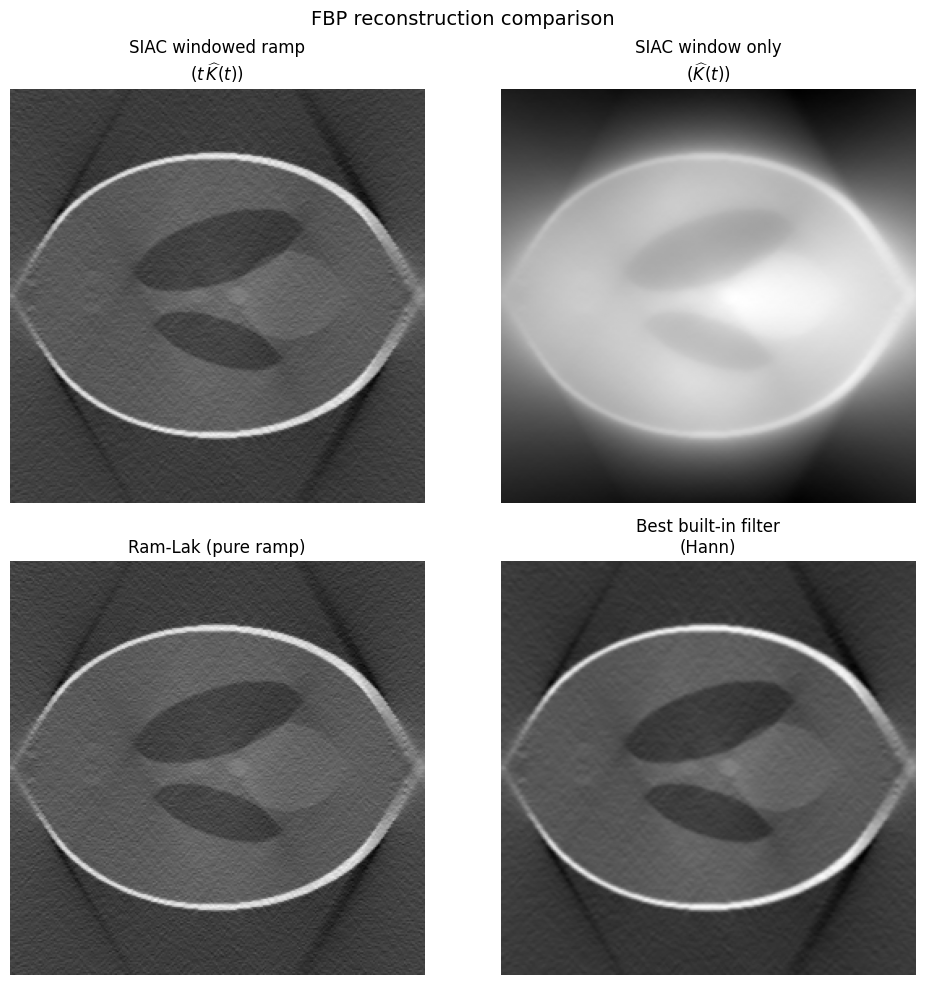

In [20]:

def siac_filter_odl(moments, BSorder, include_ramp=True):
    """
    Return an ODL-compatible frequency filter callable.

    Parameters
    ----------
    moments : int
        Polynomial reproduction order (even).
    BSorder : int
        B-spline order.
    include_ramp : bool, optional
        If True (default), return t * K̂(t) (FBP-style windowed ramp).
        If False, return K̂(t) only (pure SIAC window).
    """
    cgam = siac_cgam(moments, BSorder)

    def filt(t):
        t = np.asarray(t, dtype=float)
        t = np.clip(t, 0.0, 1.0)

        # Dimensionless frequency
        w = np.pi * t

        # Cosine series
        cterm = cgam[0] * np.ones_like(w)
        for gamma in range(1, len(cgam)):
            cterm += 2.0 * cgam[gamma] * np.cos(gamma * w)

        # B-spline factor
        sinc_term = np.sinc(w / (2.0 * np.pi)) ** BSorder

        Khat = sinc_term * cterm

        if include_ramp:
            return t * Khat   # Ram-Lak x SIAC window
        else:
            return Khat       # SIAC window only

    return filt

fbp_custom = odl.tomo.fbp_op(
    A,
    filter_type=siac_filter_odl(moments=2, BSorder=2),
    padding=True,
    frequency_scaling=1.0
)
fbp_window_only = odl.tomo.fbp_op(
    A,
    filter_type=siac_filter_odl(moments=2, BSorder=2, include_ramp=False),
    padding=True,
    frequency_scaling=1.0
)


from matplotlib.lines import Line2D

t = np.linspace(0.0, 1.0, 2001)

moments_list = [2, 4]
BSorder_list = [2, 4, 8, 12]

# Reference filters
H_ramp = _fbp_filter_patched(t, filter_type="Ram-Lak", frequency_scaling=1.0)
H_best = _fbp_filter_patched(t, filter_type=best_filter, frequency_scaling=1.0)

# Style maps
colors = {2: "C0", 4: "C1"}  # same color for same moments

# Use explicit dash patterns to make legend styles unmistakable
dash_map = {
    2: None,              # solid
    4: (6, 3),            # dashed
    8: (1, 2),            # dotted
    12: (6, 2, 1, 2),      # dash-dot
}

plt.figure(figsize=(7, 4.5))

# Plot SIAC windowed ramp for each combo
for m in moments_list:
    for p in BSorder_list:
        H = siac_filter_odl(m, p, include_ramp=True)(t)
        (line,) = plt.plot(
            t, H,
            color=colors[m],
            linewidth=2.0 if p in (2, 4) else 1.8,
            alpha=0.95
        )
        # apply dash pattern (solid if None)
        if dash_map[p] is not None:
            line.set_dashes(dash_map[p])

# Plot references (store handles)
(ref_ramp,) = plt.plot(t, H_ramp, color="k", linewidth=1.8, linestyle="--", label="Ram-Lak (ramp)")
(ref_best,) = plt.plot(t, H_best, color="k", linewidth=2.2, linestyle="-", alpha=0.85,
                       label=f"Best built-in ({best_filter})")

plt.xlabel("Normalized frequency $t \\in [0,1]$")
plt.ylabel("Filter magnitude")
plt.title("Effect of SIAC parameters on windowed ramp filter $t\\,\\widehat K(t)$")
plt.grid(True, alpha=0.25)

ax = plt.gca()

# --- Left legend: references + moments (colors) ---
handles_left = [
    ref_ramp,
    ref_best,
    Line2D([0], [0], color=colors[2], lw=2.5, linestyle="-", label="moments = 2"),
    Line2D([0], [0], color=colors[4], lw=2.5, linestyle="-", label="moments = 4"),
]
leg1 = ax.legend(
    handles=handles_left,
    title="References + moment order (color)",
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    handlelength=3.0
)
ax.add_artist(leg1)

# --- Right legend: BSorder (dash style) ---
handles_right = []
for p in BSorder_list:
    h = Line2D([0], [0], color="0.3", lw=2.5, linestyle="-", label=f"BSorder = {p}")
    if dash_map[p] is not None:
        h.set_dashes(dash_map[p])
    handles_right.append(h)

ax.legend(
    handles=handles_right,
    title="B-spline order (dash style)",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    handlelength=3.5
)

plt.tight_layout()
plt.show()



fbp_img_SIAC_ramp = fbp_custom(sino_noisy)
fbp_img_SIAC = fbp_window_only(sino_noisy)

# make subplots
fbp_img_SIAC_ramp = fbp_img_SIAC_ramp.asarray()
fbp_img_SIAC = fbp_img_SIAC.asarray()

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# --- SIAC-based reconstructions ---
axes[0, 0].imshow(fbp_img_SIAC_ramp, cmap="gray")
axes[0, 0].set_title("SIAC windowed ramp\n($t\,\widehat K(t)$)")
axes[0, 0].axis("off")

axes[0, 1].imshow(fbp_img_SIAC, cmap="gray")
axes[0, 1].set_title("SIAC window only\n($\widehat K(t)$)")
axes[0, 1].axis("off")

# --- Reference / baseline reconstructions ---
axes[1, 0].imshow(fbp_ref, cmap="gray")
axes[1, 0].set_title("Ram-Lak (pure ramp)")
axes[1, 0].axis("off")

axes[1, 1].imshow(fbp_best, cmap="gray")
axes[1, 1].set_title(f"Best built-in filter\n({best_filter})")
axes[1, 1].axis("off")

fig.suptitle("FBP reconstruction comparison", fontsize=14)
plt.tight_layout()
plt.show()

plt.show()  # to not get duplicated plots for the last one


### Plotting splines defined by repeated convolution (centered)

Define the unit box as
$$
B_1(x) = \chi_{[-1/2,\,1/2)} =
\begin{cases}
1, & x \in [-1/2,\,1/2),\\
0, & \text{else}.
\end{cases}
$$

Higher–order splines are defined by repeated self–convolution,
$$
B_{n+1}(x) = (B_1 * B_n)(x)
= \underbrace{\chi_{[-1/2,\,1/2)} * \chi_{[-1/2,\,1/2)} * \cdots * \chi_{[-1/2,\,1/2)}}_{n+1\ \text{times}}.
$$

The Fourier transform of the first spline is
$$
\widehat B_1(\xi)
= \mathcal{F}[B_1](\xi)
= \int_{\mathbb R} \chi_{[-1/2,\,1/2)}(x)\, e^{-i2\pi\xi x}\,dx,
\qquad \xi\in\mathbb R.
$$

Since the support of $B_1$ is $[-1/2,1/2)$, this reduces to
$$
\widehat B_1(\xi)
= \int_{-1/2}^{1/2} e^{-i2\pi\xi x}\,dx
= \left[\frac{e^{-i2\pi\xi x}}{-i2\pi\xi}\right]_{-1/2}^{1/2}
= \frac{e^{-i\pi\xi}-e^{i\pi\xi}}{-i2\pi\xi}
= \frac{\sin(\pi\xi)}{\pi\xi}.
$$

Hence
$$
\widehat B_1(\xi) = \operatorname{sinc}(\xi),
\qquad
\operatorname{sinc}(\xi) := \frac{\sin(\pi\xi)}{\pi\xi}.
$$

By the convolution theorem, repeated convolution in physical space corresponds to multiplication in Fourier space. Therefore,
$$
\widehat B_n(\xi)
= \bigl(\widehat B_1(\xi)\bigr)^n
= \operatorname{sinc}(\xi)^n,
\qquad n \ge 1.
$$

In particular,
$$
\widehat B_2(\xi) = \operatorname{sinc}(\xi)^2,
\qquad
\widehat B_3(\xi) = \operatorname{sinc}(\xi)^3.
$$

Taking the inverse Fourier transform yields the first three centered splines:
$$
B_1(x) = \chi_{[-1/2,\,1/2)}(x),
$$
$$
B_2(x) =
\begin{cases}
1 - |x|, & |x| \le 1,\\
0, & \text{else},
\end{cases}
$$
$$
B_3(x) =
\begin{cases}
\frac{1}{2}(2 - |x|)^2, & 1 \le |x| < 2,\\[4pt]
\frac{3}{4} - x^2, & |x| < 1,\\
0, & \text{else}.
\end{cases}
$$


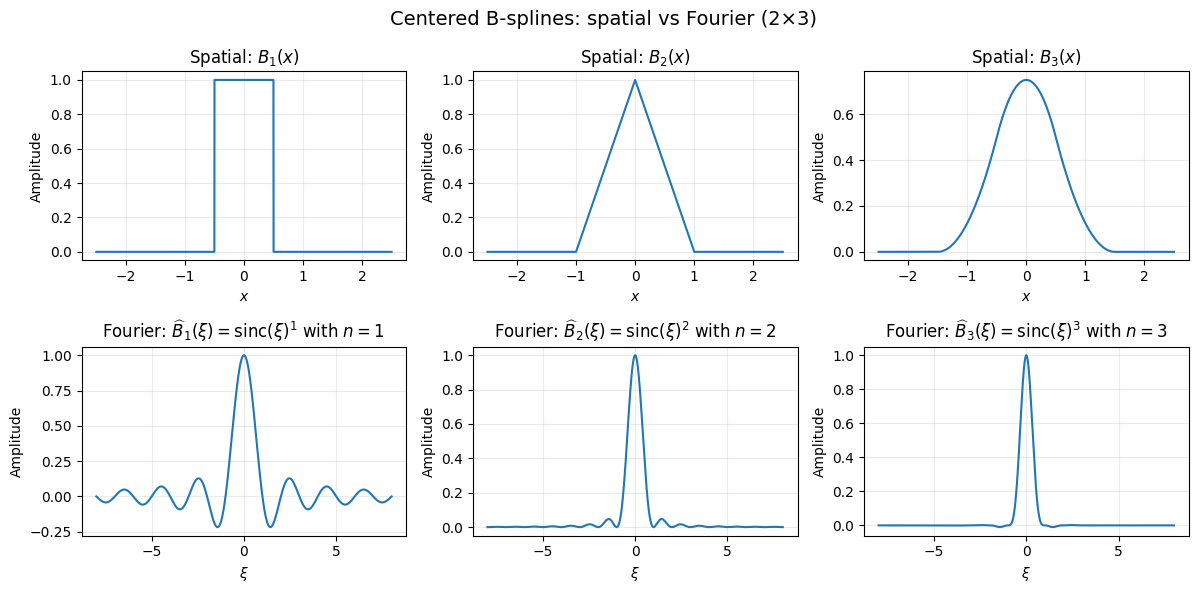

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Centered B-splines in space ----------
def B1(x):
    # box: chi_{[-1/2, 1/2)}
    return ((x >= -0.5) & (x < 0.5)).astype(float)

def B2(x):
    # hat: (1 - |x|)_+ with support [-1,1]
    ax = np.abs(x)
    return np.where(ax <= 1.0, 1.0 - ax, 0.0)

def B3(x):
    # quadratic centered B-spline (piecewise), support [-3/2, 3/2]
    ax = np.abs(x)
    out = np.zeros_like(x, dtype=float)
    # |x| < 1/2
    mask0 = ax < 0.5
    out[mask0] = 0.75 - ax[mask0]**2
    # 1/2 <= |x| < 3/2
    mask1 = (ax >= 0.5) & (ax < 1.5)
    out[mask1] = 0.5 * (1.5 - ax[mask1])**2
    return out

# ---------- Fourier transforms ----------
def sinc(xi):
    # numpy.sinc(u) = sin(pi u)/(pi u)
    return np.sinc(xi)

def Bhat_n(xi, n):
    return sinc(xi) ** n

# ---------- Plot setup ----------
# Spatial grid
x = np.linspace(-2.5, 2.5, 4001)

# Frequency grid
xi = np.linspace(-8, 8, 4001)

splines = [
    ("$B_1(x)$", B1, 1),
    ("$B_2(x)$", B2, 2),
    ("$B_3(x)$", B3, 3),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=False, sharey=False)

# Top row: spatial
for j, (title, Bfun, n) in enumerate(splines):
    y = Bfun(x)
    axes[0, j].plot(x, y)
    axes[0, j].set_title(f"Spatial: {title}")
    axes[0, j].set_xlabel("$x$")
    axes[0, j].set_ylabel("Amplitude")
    axes[0, j].grid(True, alpha=0.25)

# Bottom row: Fourier
for j, (title, Bfun, n) in enumerate(splines):
    H = Bhat_n(xi, n)
    # Plot real part (it's even and real here), can also plot magnitude: np.abs(H)
    axes[1, j].plot(xi, H)
    axes[1, j].set_title(rf"Fourier: $\widehat{{B}}_{n}(\xi)=\mathrm{{sinc}}(\xi)^{n}$ with $n={n}$")
    axes[1, j].set_xlabel(r"$\xi$")
    axes[1, j].set_ylabel("Amplitude")
    axes[1, j].grid(True, alpha=0.25)

fig.suptitle("Centered B-splines: spatial vs Fourier", fontsize=14)
plt.tight_layout()
plt.show()
